In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np
import sqlite3
import pandas as pd
import folium
from geopy.geocoders import Nominatim
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

## Database connection and EDA

In [6]:
conn = sqlite3.connect('yelp.db')

In [7]:
tables = pd.read_sql("""SELECT name FROM sqlite_master WHERE type='table';""", conn)
tables

,name
0,business
1,checkin
2,review
3,tip
4,user


In [8]:
for table in tables['name']:
  display(pd.read_sql(f"SELECT * FROM {table} LIMIT 5;", conn))

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,categories
0,TacYUYhU3HpLHF9Rs6fW2w,Steps to Learning Montessori Preschool,6901 Phelps Rd,Goleta,CA,93117,34.423311,-119.870637,4.5,8,1,"Education, Elementary Schools, Child Care & Da..."
1,RnExaICvIeXxFpbIKEqJsQ,Breeze Blow Dry Bar,9916 Clayton Rd,St. Louis,MO,63124,38.636716,-90.393139,4.0,81,0,"Hair Salons, Beauty & Spas, Hair Stylists, Ski..."
2,pjtjBeZC3gvmtIiIQt-DFA,Impact Guns,11655 W Executive Dr,Boise,ID,83713,43.608700,-116.328000,3.0,39,1,"Gun/Rifle Ranges, Active Life"
3,OMl5pTUBVUjW_jvDKLvYtw,Palms Primary Care,"1615 Pasadena Ave S, Ste 430",Saint Petersburg,FL,33707,27.752653,-82.741325,4.0,5,1,"Internal Medicine, Doctors, Health & Medical"
4,MO-LTDfO843xaRtW0bx6jQ,J&Q Nails,"9655 E US Hwy 36, Unit H",Avon,IN,46123,39.763059,-86.352280,3.5,28,1,"Nail Salons, Hair Removal, Beauty & Spas, Waxing"


,business_id,date
0,IjAjccegjWKQPu41iuMpZQ,"2015-08-19 22:01:18, 2015-08-26 20:35:30, 2015..."
1,JrYWF3BWf1GYk8hnF2Cz4w,"2015-08-13 22:59:33, 2015-12-31 19:23:01, 2016..."
2,iKjXWDjdv9N7fT6kgGKM6g,"2015-06-11 17:42:50, 2015-09-25 22:00:32, 2015..."
3,hkuIjzyewr7RyIbKvjUQ5A,"2019-06-25 23:10:05, 2019-10-16 18:21:41, 2019..."
4,crgS4ogZEt2rYGwYVfeK2A,"2016-09-02 22:34:41, 2016-09-05 21:20:35, 2016..."


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,J5Q1gH4ACCj6CtQG7Yom7g,56gL9KEJNHiSDUoyjk2o3Q,8yR12PNSMo6FBYx1u5KPlw,2.0,1,0,0,Went for lunch and found that my burger was me...,2018-04-04 21:09:53
1,HlXP79ecTquSVXmjM10QxQ,bAt9OUFX9ZRgGLCXG22UmA,pBNucviUkNsiqhJv5IFpjg,5.0,0,0,0,I needed a new tires for my wife's car. They h...,2020-05-24 12:22:14
2,JBBULrjyGx6vHto2osk_CQ,NRHPcLq2vGWqgqwVugSgnQ,8sf9kv6O4GgEb0j1o22N1g,5.0,0,0,0,Jim Woltman who works at Goleta Honda is 5 sta...,2019-02-14 03:47:48
3,U9-43s8YUl6GWBFCpxUGEw,PAxc0qpqt5c2kA0rjDFFAg,XwepyB7KjJ-XGJf0vKc6Vg,4.0,0,0,0,Been here a few times to get some shrimp. The...,2013-04-27 01:55:49
4,8T8EGa_4Cj12M6w8vRgUsQ,BqPR1Dp5Rb_QYs9_fz9RiA,prm5wvpp0OHJBlrvTj9uOg,5.0,0,0,0,This is one fantastic place to eat whether you...,2019-05-15 18:29:25


,user_id,business_id,text,date,compliment_count
0,mpS38CQozjwcWPa231SouQ,08q4nEOcz9hc1lRW7UPOng,The Herb Roasted Salmon is great....,2014-03-09 01:27:09,0
1,zoQQfvhUJkaC1a_Dve4Rbg,VJJvf5TwX2xXn2mFducV6w,Auditions,2012-07-06 21:55:26,0
2,WMyzz4hy0oE0lEpYv4NGBw,YCPhdj_9t7o_NdN76WKJVg,One of my fave spots in Tampa bay! Double yum!,2012-01-29 16:25:07,0
3,oAvO0BOHOagOI7WVGXlWSA,2tSWTVynoI7Sc_BhGHsO9Q,The store here is well organized. I'm impressed,2013-05-05 20:37:43,0
4,SuTsOvXdCYdkyOSzOKI1eQ,nTBStZYJfHGdSZJbpaBiPA,If you want that traditional old diner experie...,2014-04-23 22:16:19,0


,user_id,name,review_count,yelping_since,useful,funny,cool,elite,friends,fans,...,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
0,QQaKfSyWbzZTVqUuIoefow,Corrin,2,2015-08-03 00:00:35,4,1,0,,"UHYW5gz-n-VnRv4k0NLgZQ, EzAnwduLSyO62kb-O0NK5Q...",1,...,0,0,0,0,0,0,0,0,0,0
1,epRxgIf-3HAJggkp4OSFtA,Lois,1,2016-11-13 16:35:24,1,0,0,,None,0,...,0,0,0,0,0,0,0,0,0,0
2,dkcKCYISLc9nGfgMJ5ZitA,Desiree,26,2011-01-15 19:28:26,18,0,3,,"e9QIeB_tgzXTCKmrvzQJiw, AaDd1GNo_0Du3lXg_cD7cw...",3,...,0,0,0,0,3,0,1,1,0,0
3,yUyveO0V0BxSklVauJvD0g,Gary,1,2015-06-04 15:21:26,1,0,1,,None,0,...,0,0,0,0,1,0,0,0,0,0
4,txOVgP4grDuL2PjbQX3Bxw,Shawne,2,2015-09-13 01:17:40,0,0,0,,None,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
pd.read_sql_query("SELECT COUNT(*) FROM business", conn)

,COUNT(*)
0,15035


### Checking for open restaurant businesses

In [42]:
business_df = pd.read_sql_query("""
SELECT 
    business_id,
    name, 
    review_count 
FROM business 
WHERE LOWER(categories) LIKE '%restaurant%' AND is_open = 1
""", conn)

business_df

,business_id,name,review_count
0,6XOn1p3sbO22UjJGpmCgxg,China Wok,20
1,rbPK4jSyFS10zhWYvo_Srg,Cafe Porche and snowbar,172
2,udjadmbL9mx5VXb7sKOdWg,Subway,7
3,TghikeYc56lcmet_KwkYCA,Arby's,11
4,GWajXz5cKulo-5A1wCKv8Q,McDonald's,28
...,...,...,...
3481,b_jg4hexYmhJoo8c4P6MoA,El Metate Auténtico Mexicán Restaurant,101
3482,LxFKs9B1BXaF-m_yNGKA9g,Chick-fil-A,20
3483,N9g4lGJbzQzJCUf6AF7d7Q,Fork & Function on Central,21
3484,7Qi2oZY5vgCcQb3g6iNeyw,Bynum's Steakhouse,157


### Distribution of business success metrics (review_count and average rating)

In [44]:
pd.read_sql_query(f"""
SELECT 
  AVG(review_count) AS avg_review_count,
  MIN(review_count) AS min_review_count, 
  MAX(review_count) AS max_review_count,
  (SELECT review_count 
   FROM business 
   ORDER BY review_count 
   LIMIT 1 OFFSET CAST((SELECT COUNT(*) FROM business)/2 AS INTEGER)
  ) AS median_review_count,

  AVG(stars) AS avg_star_rating,
  MIN(stars) AS min_star_rating, 
  MAX(stars) AS max_star_rating,
  (SELECT stars 
   FROM business 
   ORDER BY stars 
   LIMIT 1 OFFSET CAST((SELECT COUNT(*) FROM business)/2 AS INTEGER)
  ) AS median_star_rating
FROM business
WHERE business_id IN {tuple(business_df['business_id'])};

""", conn).transpose()

,0
avg_review_count,105.276535
min_review_count,5.000000
max_review_count,3582.000000
median_review_count,14.000000
avg_star_rating,3.551348
min_star_rating,1.000000
max_star_rating,5.000000
median_star_rating,3.500000


In [45]:
def remove_outliers(df, col):
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr
  return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [46]:
business_id = remove_outliers(business_df, 'review_count')
business_id.shape

(3128, 3)

### Restaurants with highest no. of reviews

In [47]:
pd.read_sql_query(f"""
SELECT 
  name, 
  SUM(review_count) AS total_reviews,
  AVG(stars) AS avg_star_rating
FROM business
WHERE business_id IN {tuple(business_df['business_id'])}
GROUP BY name
ORDER BY total_reviews DESC
LIMIT 10;
""", conn)

,name,total_reviews,avg_star_rating
0,Willie Mae's Scotch House,3582,4.50
1,Barbuzzo,2893,4.50
2,Boathouse at Hendry's Beach,2536,4.00
3,Deanie's Seafood,2473,3.50
4,Stanley,2406,4.00
5,Surrey's Café & Juice Bar,2084,4.50
6,Cafe Fleur De Lis,1865,4.00
7,Salt + Smoke,1825,4.25
8,Fork,1810,4.00
9,Acme Feed & Seed,1731,4.00


### Restaurants with highest ratings

In [48]:
pd.read_sql_query(f"""
SELECT 
  name, 
  SUM(review_count) AS total_reviews,
  AVG(stars) AS avg_star_rating
FROM business
WHERE business_id IN {tuple(business_df['business_id'])}
GROUP BY name
ORDER BY avg_star_rating DESC
LIMIT 10;
""", conn)

,name,total_reviews,avg_star_rating
0,Zlatno Zito,36,5.0
1,Yinzer’s Amazing Cheesesteaks,24,5.0
2,Yankee Chipper,18,5.0
3,Xtreme Tacos - Seminole Heights,145,5.0
4,Wolly’s Kitchen,10,5.0
5,Westbrook Market,6,5.0
6,Warfuel Kitchen,5,5.0
7,Virginia's Market,6,5.0
8,Vince's Pizzeria of Fishtown,22,5.0
9,Uptown Eats,57,5.0


### Engagement rate vs ratings

In [51]:
pd.read_sql_query("""
SELECT
  business_id,
  SUM(length(date) - length(replace(date, ',', '')) + 1) AS checkin_count
FROM checkin
GROUP BY business_id
ORDER BY checkin_count DESC
LIMIT 10;
""", conn)

,business_id,checkin_count
0,wz8ZPfySQczcPgSyd33-HQ,10478
1,oBNrLz4EDhiscSlbOl8uAw,10209
2,U3grYFIeu6RgAAQgdriHww,6528
3,VVH6k9-ycttH3TV_lk5WfQ,6326
4,uvGfk8eirExWR-B9zsIN5Q,5280
5,IWHdx0NhDKADkGOgXgOFKQ,4951
6,oIH5YWPy_g61YXM6R900Wg,4691
7,8pqdJjefYq-a9IBSJJmKwA,4656
8,1b5mnK8bMnnju_cvU65GqQ,4467
9,Sv1MEZP-mMfp8SmE0hwYEA,4016


In [52]:
pd.read_sql_query("""
SELECT
  business_id,
  COUNT(*) AS tip_count
FROM tip
GROUP BY business_id
ORDER BY tip_count DESC
LIMIT 10;
""", conn)

,business_id,tip_count
0,FEXhWNCMkv22qG04E83Qjg,142
1,-QI8Qi8XWH3D8y8ethnajA,56
2,Eb1XmmLWyt_way5NNZ7-Pw,55
3,ytynqOUb3hjKeJfRj5Tshw,46
4,_ab50qdWOk0DdB6XOrBitw,46
5,c_4c5rJECZSfNgFj7frwHQ,42
6,oBNrLz4EDhiscSlbOl8uAw,39
7,iSRTaT9WngzB8JJ2YKJUig,35
8,8O35ji_yOMVJmZ6bl96yhQ,35
9,gTC8IQ_i8zXytWSly3Ttvg,34


In [53]:
review_count_df = pd.read_sql_query(f"""
SELECT
  total.avg_rating AS rating,
  AVG(total.review_count) AS avg_review_count,
  AVG(total.checkin_count) AS avg_checkin_count,
  AVG(total.tip_count) AS avg_tip_count
FROM
  (SELECT
    b.business_id,
    AVG(b.stars) AS avg_rating,
    SUM(b.review_count) AS review_count,
    SUM(LENGTH(cc.date) - LENGTH(REPLACE(cc.date, ',', '')) + 1) AS checkin_count,
    SUM(tip.tip_count) AS tip_count
  FROM business b
  LEFT JOIN checkin cc ON b.business_id = cc.business_id
  LEFT JOIN
    (SELECT business_id, count(business_id) AS tip_count FROM tip GROUP BY business_id ORDER BY tip_count) AS tip
  ON b.business_id = tip.business_id
  WHERE b.business_id IN {tuple(business_df['business_id'])}
  GROUP BY b.business_id) AS total
GROUP BY total.avg_rating
ORDER BY total.avg_rating DESC;

""", conn)

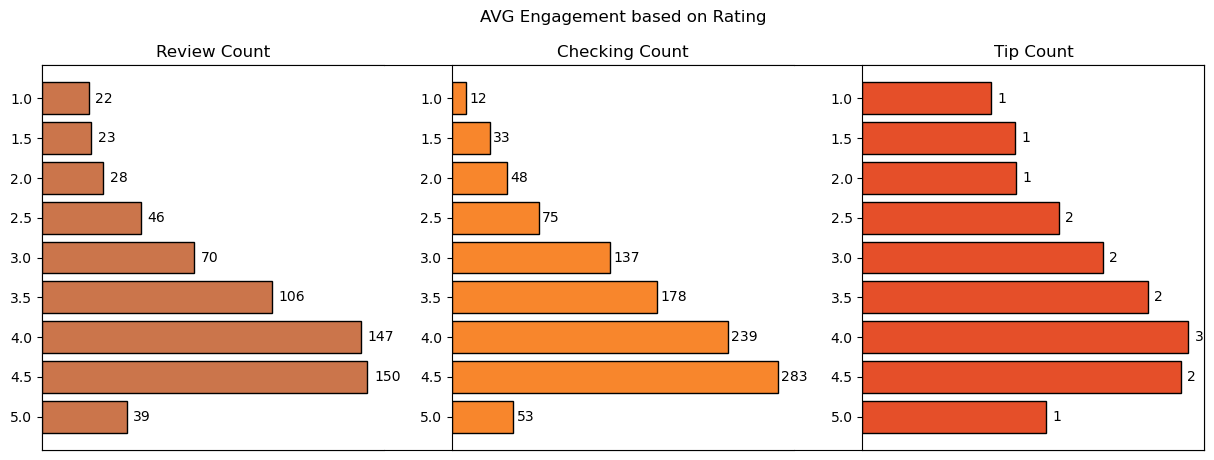

In [54]:
plt.figure(figsize=(15, 5))
plt.title('AVG Engagement based on Rating\n\n')
plt.yticks([])
plt.xticks([])
plt.subplot(1,3,1)
plt.title('Review Count')
plt.barh(review_count_df['rating'].astype('str'), review_count_df['avg_review_count'], edgecolor = 'k', color = '#CB754B')
plt.gca().spines['right'].set_visible(False)
for i, value in enumerate(review_count_df['avg_review_count']):
    plt.text(value+3, i, str(round(value)), color = 'black', va='center')

plt.xticks([])
plt.subplot(1,3,2)
plt.title('Checking Count')
plt.barh(review_count_df['rating'].astype('str'), review_count_df['avg_checkin_count'], edgecolor = 'k', color = '#f8862C')
plt.gca().spines['right'].set_visible(False)
for i, value in enumerate(review_count_df['avg_checkin_count']):
    plt.text(value+3, i, str(round(value)), color = 'black', va='center')

plt.xticks([])
plt.subplot(1,3,3)
plt.title('Tip Count')
plt.barh(review_count_df['rating'].astype('str'), review_count_df['avg_tip_count'], edgecolor = 'k', color = '#E54f29')
for i, value in enumerate(review_count_df['avg_tip_count']):
    plt.text(value+0.05, i, str(round(value)), color = 'black', va='center')
    
plt.xticks([])
plt.show()

### Correlation btwn no. reviews, tips and check-ins for a business

In [66]:
engagement_df = pd.read_sql_query(f"""
SELECT
  b.business_id,
  b.categories,
  AVG(b.stars) AS avg_rating,
  SUM(b.review_count) AS review_count,
  SUM(LENGTH(cc.date) - LENGTH(REPLACE(cc.date, ',', '')) + 1) AS checkin_count,
  SUM(tip.tip_count) AS tip_count,
  CASE
    WHEN b.stars >= 3.5 THEN 'High-Rated'
    ELSE 'Low-Rated'
  END AS rating_category
  FROM business b
  LEFT JOIN checkin cc ON b.business_id = cc.business_id
  LEFT JOIN
    (SELECT business_id, count(business_id) AS tip_count FROM tip GROUP BY business_id ORDER BY tip_count) AS tip ON b.business_id = tip.business_id
  WHERE b.business_id IN {tuple(business_df['business_id'])}
  GROUP BY b.business_id, b.categories

""", conn).dropna()

In [67]:
corr_matrix = engagement_df[['review_count', 'checkin_count', 'tip_count']].corr()
corr_matrix

,review_count,checkin_count,tip_count
review_count,1.000000,0.939277,0.823851
checkin_count,0.939277,1.000000,0.862134
tip_count,0.823851,0.862134,1.000000


<Axes: >

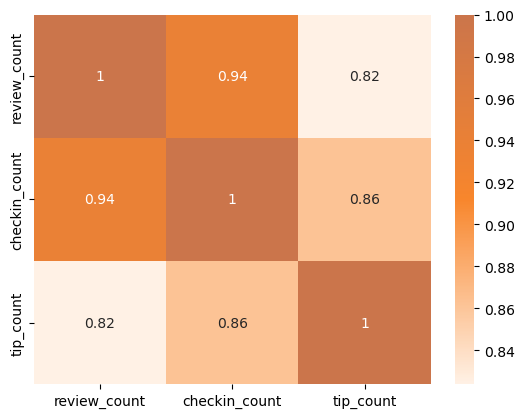

In [68]:
colors = ['#fff1E5', '#f8862C', '#CB754B']
custom_cmap = LinearSegmentedColormap.from_list("mycmap", colors)
sns.heatmap(engagement_df[['review_count', 'checkin_count', 'tip_count']].corr(), cmap = custom_cmap, annot = True)

### Difference in the user engagement (reviews, tips, check-ins) btwn high-rated and low-rated businesses

In [69]:
engagement_df.groupby('categories')[['review_count', 'tip_count', 'checkin_count']].mean()

,review_count,tip_count,checkin_count
categories,,,
"Acai Bowls, Restaurants, Ice Cream & Frozen Yogurt, Wraps, Salad, Food, Juice Bars & Smoothies",50.0,2.0,115.0
"American (New), Bars, Food, Pubs, Breweries, Pizza, Restaurants, Nightlife",221.0,1.0,515.0
"American (New), Caterers, Food, American (Traditional), Venues & Event Spaces, Bars, Nightlife, Event Planning & Services, Beer, Wine & Spirits, Restaurants",131.0,1.0,158.0
"American (New), Italian, Restaurants, Event Planning & Services, Food, Coffee & Tea, Caterers",359.0,4.0,190.0
"American (New), Venues & Event Spaces, Nightlife, Restaurants, Hotels & Travel, Hotels, Event Planning & Services, Lounges, Bars",93.0,1.0,71.0
...,...,...,...
"Sports Bars, Bars, American (Traditional), Restaurants, Nightlife",84.0,1.0,167.0
"Sushi Bars, Restaurants",56.0,1.0,56.0
"Tapas/Small Plates, Event Planning & Services, Specialty Food, Caterers, Food, Venues & Event Spaces, Cocktail Bars, Breakfast & Brunch, Burgers, Italian, Pizza, Nightlife, American (New), Restaurants, Wine Bars, Bars",457.0,2.0,916.0


In [70]:
# func to calc success score based on avg rating & total review count
def calculate_success_metric(df):
  success_score = []
  for index, row in df.iterrows():
    score = row['avg_rating'] = np.log(row['review_count'] + 1)
    success_score.append(score)
  return success_score

### Success metrics by states & cities

In [74]:
city_df = pd.read_sql_query(f"""
SELECT
  city,
  state,
  latitude,
  longitude,
  SUM(review_count) AS review_count,
  AVG(stars) AS avg_rating,
  COUNT(*) AS restaurant_count
FROM business
WHERE business_id IN {tuple(business_df['business_id'])}
GROUP BY city, state
ORDER BY review_count DESC
LIMIT 10;

""", conn)

city_df['success_score'] = calculate_success_metric(city_df)

city_df

,city,state,latitude,longitude,review_count,avg_rating,restaurant_count,success_score
0,Philadelphia,PA,39.977453,-75.124528,46225,3.585635,362,10.741298
1,New Orleans,LA,29.939316,-90.078939,36007,3.782946,129,10.491496
2,Tampa,FL,28.032146,-82.641972,23395,3.574586,181,10.060320
3,Nashville,TN,36.157939,-86.799228,22541,3.636111,180,10.023136
4,Reno,NV,39.510409,-119.836471,19821,3.767857,84,9.894548
5,Tucson,AZ,32.221908,-110.910084,19272,3.440828,169,9.866460
6,Indianapolis,IN,39.746507,-86.272258,18527,3.544041,193,9.827038
7,Santa Barbara,CA,34.439041,-119.749199,17891,4.030612,49,9.792109
8,Saint Louis,MO,38.486761,-90.304813,11246,3.534653,101,9.327857
9,Boise,ID,43.619351,-116.251324,6351,3.683333,60,8.756525


In [76]:
# Dropping rows with missing values
city_df = city_df.dropna(subset=['latitude', 'longitude', 'success_score'])

# base map
map = folium.Map(location=[city_df['latitude'].mean(), city_df['longitude'].mean()], zoom_start=4)

# Defining a color scale
color_scale = folium.LinearColormap(colors=['green', 'yellow', '#E54f29'],
                                    vmin=city_df['success_score'].min(),
                                    vmax=city_df['success_score'].max(),
                                    caption='Success Score')

# Adding markers
for index, row in city_df.iterrows():
    popup = folium.Popup(f"City: {row['city']}<br>State: {row['state']}<br>Review Count: {row['review_count']}<br>Average Rating: {row['avg_rating']}", max_width=300)
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color=color_scale(row['success_score']),
        fill=True,
        fill_color=color_scale(row['success_score']),
        fill_opacity=0.7,
        popup=popup
    ).add_to(map)

# Adding color scale to map
map.add_child(color_scale)

map

### User engagement patterns over time for successful businesses vs less successful ones

In [78]:
# checking for seasonal trends in user engagements
high_rated_engagement = pd.read_sql_query(f"""
SELECT 
  review.month_year,
  review.review_count,
  tip.tip_count
FROM
  (SELECT
    strftime('%m-%Y', date) AS month_year,
    COUNT(*) AS review_count
  FROM review
  WHERE business_id IN {tuple(business_df['business_id'])} AND stars >= 3.5
  GROUP BY month_year
  ORDER BY month_year) AS review
JOIN 
  (SELECT 
    AVG(b.stars), 
    strftime('%m-%Y', tip.date) AS month_year, 
    COUNT(*) AS tip_count 
  FROM tip
  JOIN business b ON tip.business_id = b.business_id
  WHERE tip.business_id IN {tuple(business_df['business_id'])} AND b.stars >= 3.5
  GROUP BY month_year
  ORDER BY month_year) AS tip 
ON review.month_year = tip.month_year;
""", conn)

low_rated_engagement = pd.read_sql_query(f"""
SELECT 
  review.month_year,
  review.review_count,
  tip.tip_count
FROM
  (SELECT
    strftime('%m-%Y', date) AS month_year,
    COUNT(*) AS review_count
  FROM review
  WHERE business_id IN {tuple(business_df['business_id'])} AND stars < 3.5
  GROUP BY month_year
  ORDER BY month_year) AS review
JOIN 
  (SELECT 
    AVG(b.stars), 
    strftime('%m-%Y', tip.date) AS month_year, 
    COUNT(*) AS tip_count 
  FROM tip
  JOIN business b ON tip.business_id = b.business_id
  WHERE tip.business_id IN {tuple(business_df['business_id'])} AND b.stars < 3.5
  GROUP BY month_year
  ORDER BY month_year) AS tip
ON review.month_year = tip.month_year;
""", conn)

In [79]:
high_rated_engagement

,month_year,review_count,tip_count
0,01-2010,5,1
1,01-2011,3,4
2,01-2012,3,16
3,01-2013,7,21
4,01-2014,5,19
...,...,...,...
138,12-2017,17,21
139,12-2018,21,16
140,12-2019,24,5
141,12-2020,16,6


In [80]:
low_rated_engagement

,month_year,review_count,tip_count
0,01-2011,3,1
1,01-2012,4,8
2,01-2013,6,5
3,01-2014,2,2
4,01-2015,3,3
...,...,...,...
122,12-2016,5,1
123,12-2017,6,6
124,12-2018,9,1
125,12-2019,5,1


In [82]:
time_rating = pd.read_sql_query(f"""
SELECT 
  strftime('%m-%Y', date) AS month_year,
  AVG(stars) AS avg_rating
FROM review
WHERE business_id IN {tuple(business_df['business_id'])}
GROUP BY month_year
ORDER BY month_year

""", conn)

time_rating

,month_year,avg_rating
0,01-2009,3.500000
1,01-2010,4.200000
2,01-2011,3.333333
3,01-2012,3.428571
4,01-2013,3.307692
...,...,...
158,12-2017,4.130435
159,12-2018,3.933333
160,12-2019,4.310345
161,12-2020,3.954545


In [84]:
time_rating['month_year'] = pd.to_datetime(time_rating['month_year'])
time_rating.sort_values('month_year', inplace = True)
time_rating = time_rating[time_rating['month_year'] > '2017']

high_rated_engagement['month_year'] = pd.to_datetime(high_rated_engagement['month_year'])
high_rated_engagement.sort_values('month_year', inplace = True)
high_rated_engagement = high_rated_engagement[high_rated_engagement['month_year'] > '2017']

low_rated_engagement['month_year'] = pd.to_datetime(low_rated_engagement['month_year'])
low_rated_engagement.sort_values('month_year', inplace = True)
low_rated_engagement = low_rated_engagement[low_rated_engagement['month_year'] > '2017']

In [85]:
high_rated_engagement['avg_rating'] = time_rating['avg_rating'].values

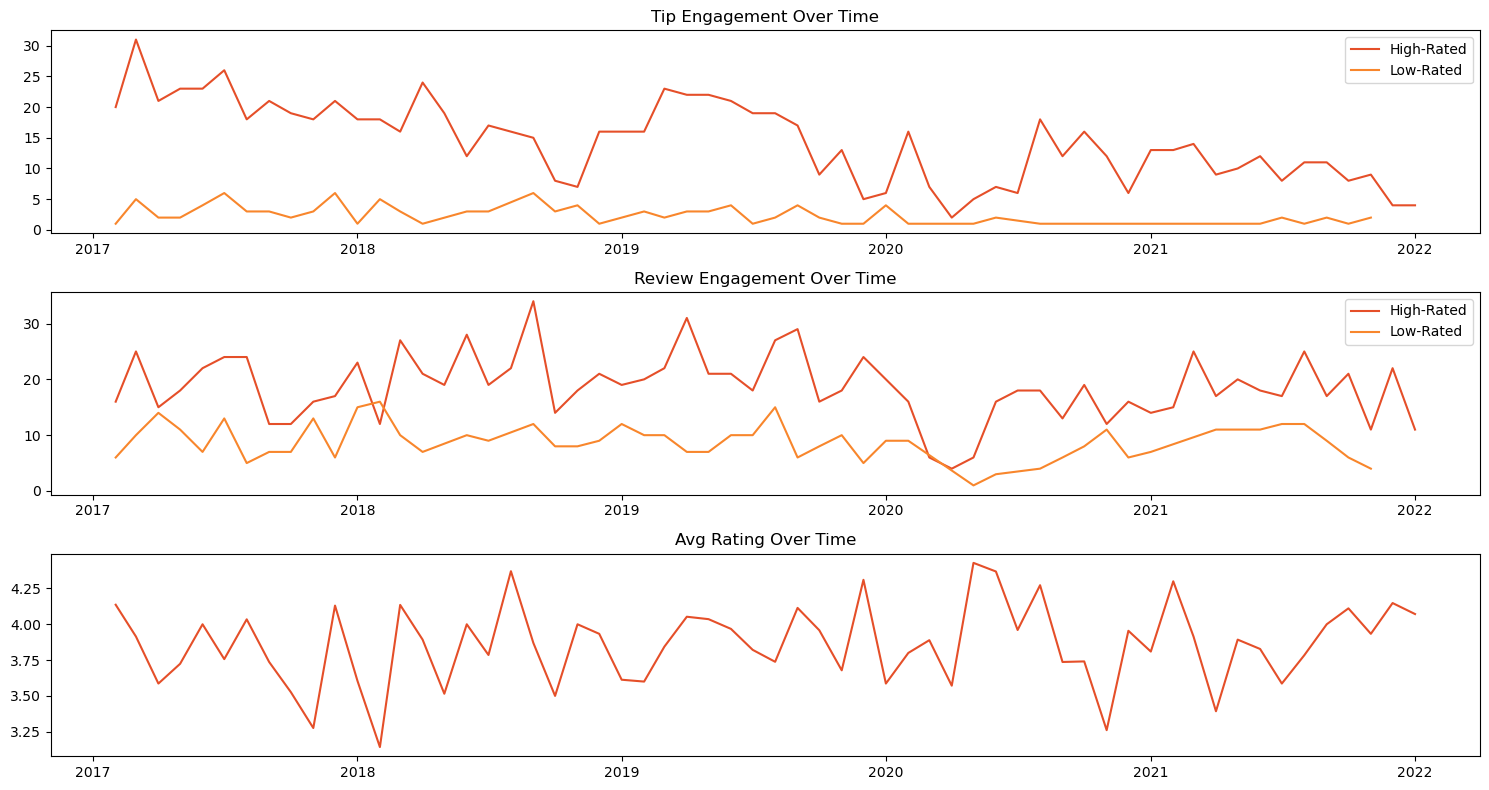

In [86]:
plt.figure(figsize=(15, 8))
plt.subplot(3,1,1)
plt.title('Tip Engagement Over Time')
plt.plot(high_rated_engagement['month_year'], high_rated_engagement['tip_count'], label = 'High-Rated', color = '#E54F29')
plt.plot(low_rated_engagement['month_year'], low_rated_engagement['tip_count'], label = 'Low-Rated', color = '#F8862C')
plt.legend()

plt.subplot(3,1,2)
plt.title('Review Engagement Over Time')
plt.plot(high_rated_engagement['month_year'], high_rated_engagement['review_count'], label = 'High-Rated', color = '#E54F29')
plt.plot(low_rated_engagement['month_year'], low_rated_engagement['review_count'], label = 'Low-Rated', color = '#F8862C')
plt.legend()

plt.subplot(3,1,3)
plt.title('Avg Rating Over Time')
plt.plot(time_rating['month_year'], time_rating['avg_rating'], color = '#E54F29')
plt.tight_layout()
plt.show()

### Trend and Seasonality Analysis

In [87]:
tip_high_rated = high_rated_engagement[['month_year', 'tip_count']].set_index('month_year')
review_high_rated = high_rated_engagement[['month_year', 'review_count']].set_index('month_year')
rating_df = time_rating[['month_year', 'avg_rating']].set_index('month_year')

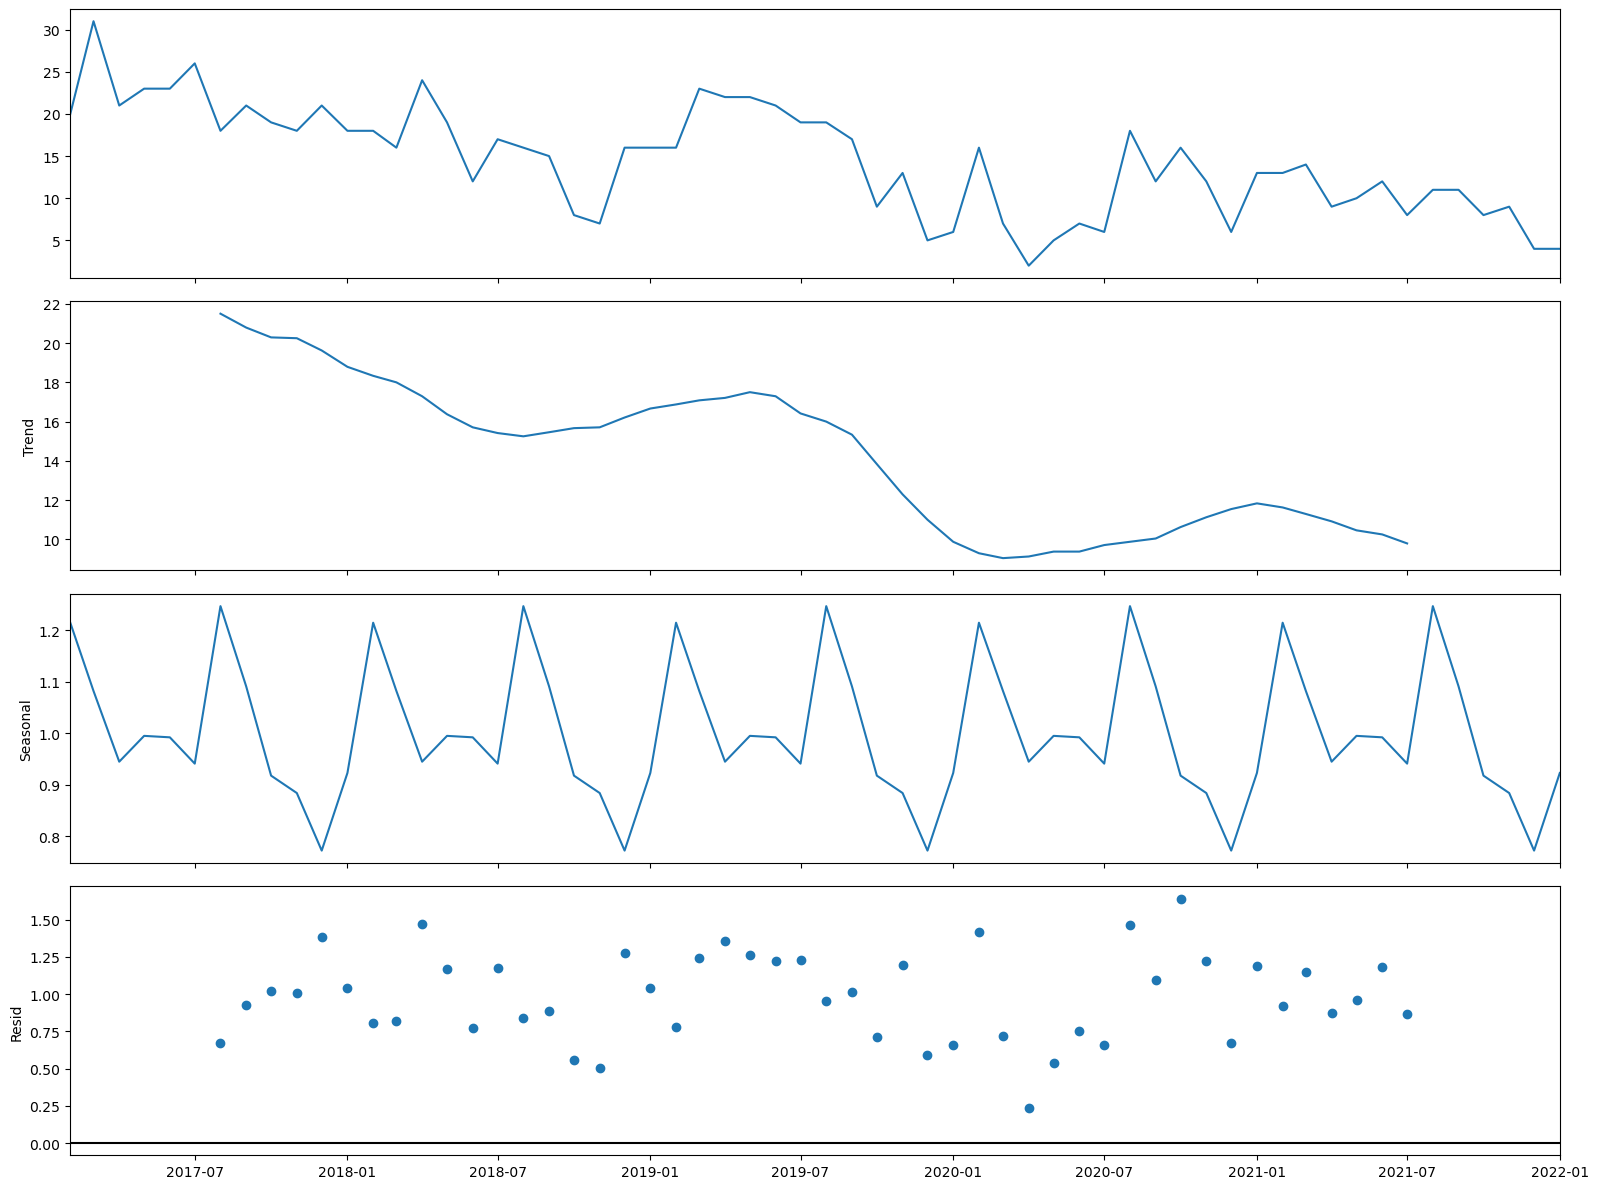

In [88]:
from statsmodels.tsa.seasonal import seasonal_decompose
multiplicative_decomposition = seasonal_decompose(tip_high_rated, model = 'multiplicative', period = 12)

plt.rcParams.update({'figure.figsize': (16, 12)})
multiplicative_decomposition.plot()
plt.show()

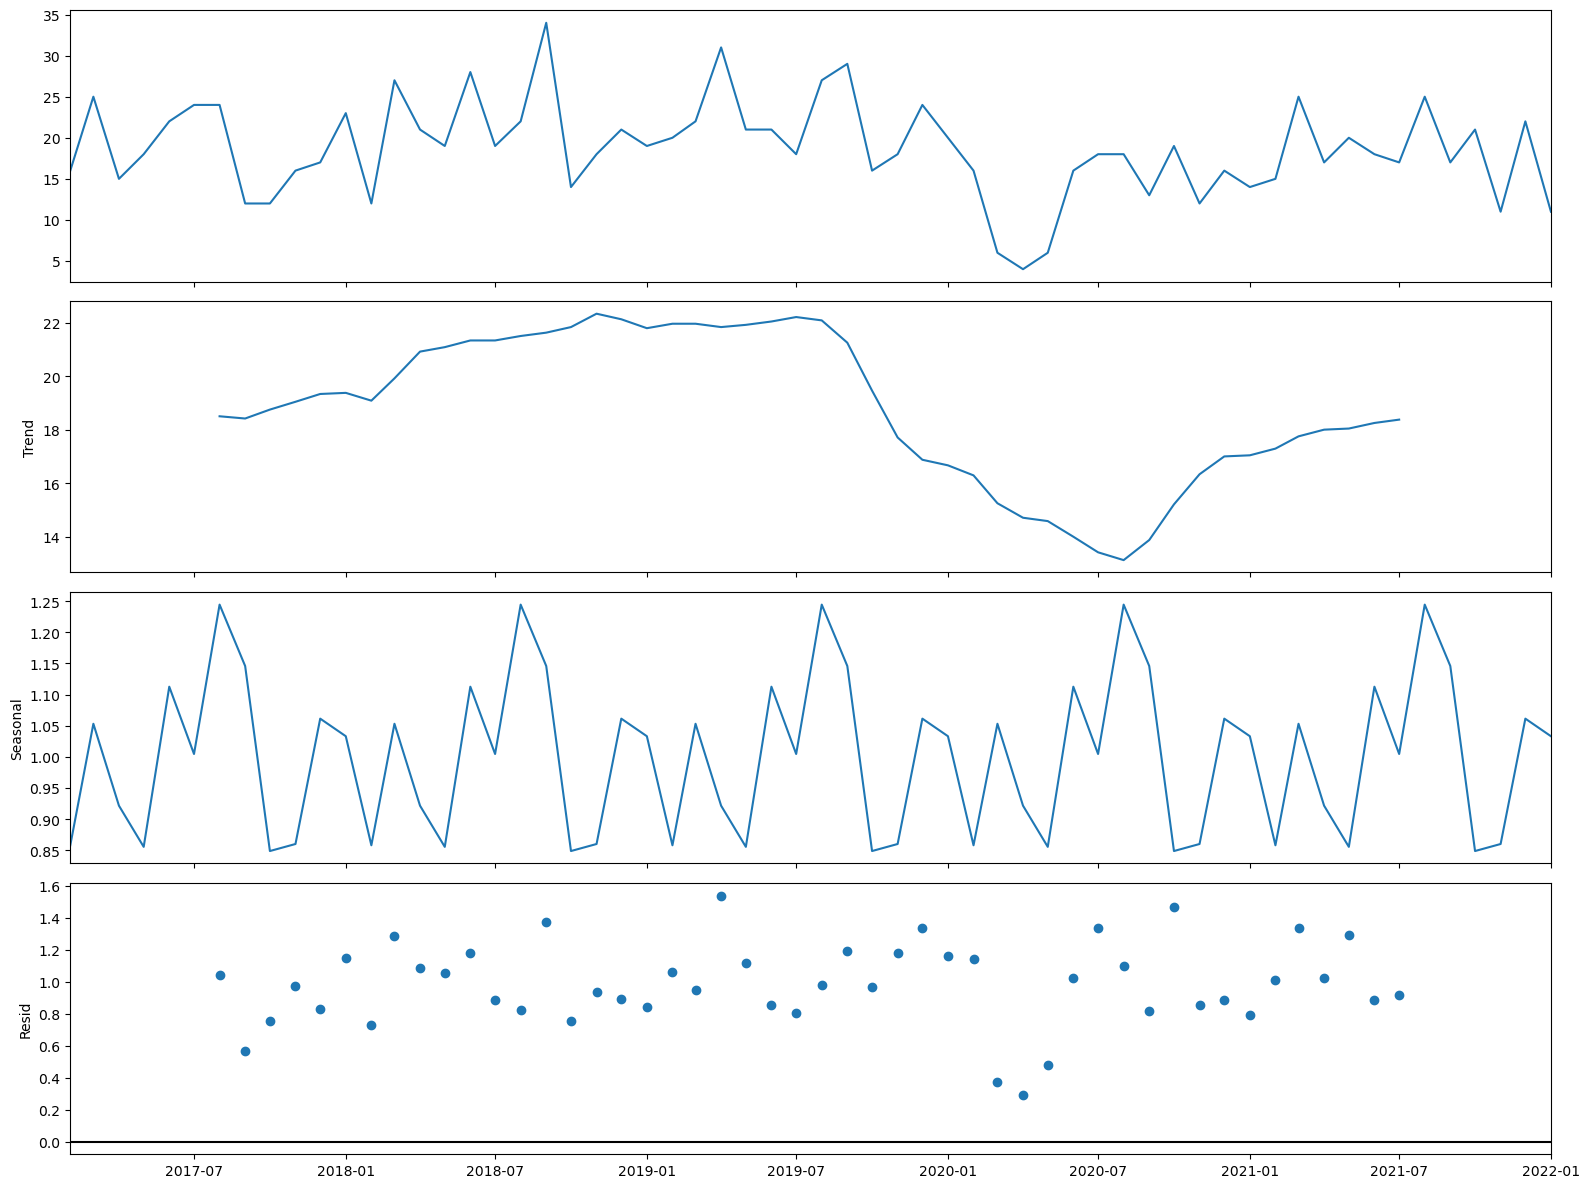

In [89]:
multiplicative_review_decomposition = seasonal_decompose(review_high_rated, model = 'multiplicative', period = 12)

plt.rcParams.update({'figure.figsize': (16, 12)})
multiplicative_review_decomposition.plot()
plt.show()

### Correlation btwn sentiment and success metrics

In [100]:
business_ids = tuple(business_df['business_id'])
if not business_ids:
    business_ids = ('',)

sentiment_df = pd.read_sql_query(f"""
SELECT
    b.business_id,
    AVG(b.stars) AS avg_rating,
    SUM(b.review_count) AS review_count,
    SUM(r.useful) AS useful_count,
    SUM(r.funny) AS funny_count,
    SUM(r.cool) AS cool_count
FROM business b
JOIN review r ON b.business_id = r.business_id
WHERE b.business_id IN {business_ids}
GROUP BY b.business_id
ORDER BY review_count;
""", conn)


In [101]:
sentiment_df = remove_outliers(sentiment_df, 'review_count')
sentiment_df = remove_outliers(sentiment_df, 'useful_count')
sentiment_df = remove_outliers(sentiment_df, 'funny_count')
sentiment_df = remove_outliers(sentiment_df, 'cool_count')

sentiment_df['success_score'] = calculate_success_metric(sentiment_df)

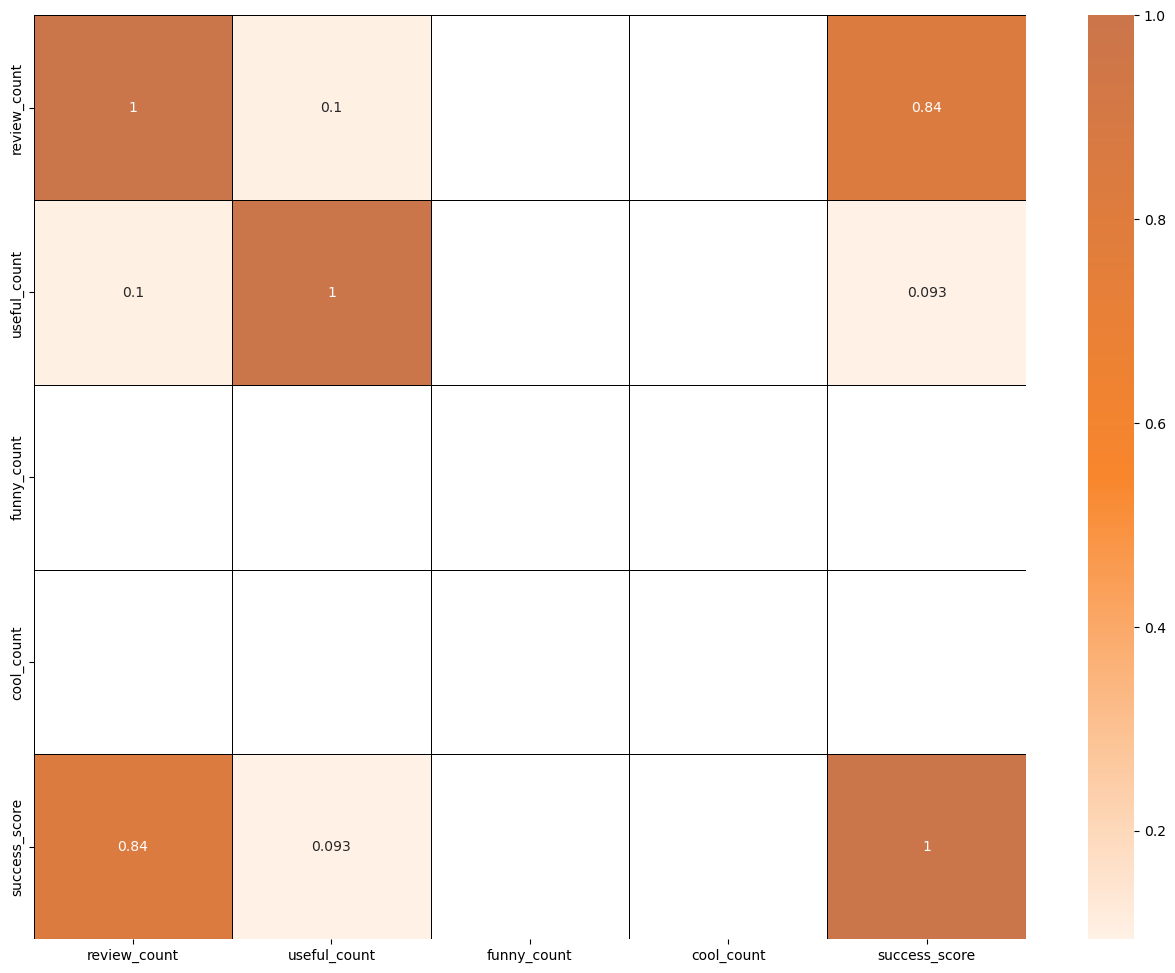

In [102]:
sns.heatmap(sentiment_df[['review_count', 'useful_count', 'funny_count', 'cool_count', 'success_score']].corr(), cmap = custom_cmap, annot = True, linewidth=0.5, linecolor='black')
plt.show()

In [ ]:
sentiment_df = pd.read_sql_query(f"""
SELECT
  b.business_id,
  AVG(b.stars) AS avg_rating,
  SUM(b.review_count) AS review_count,
  SUM(s.useful) AS useful_count,
  SUM(s.funny) AS funny_count,
  SUM(s.cool) AS cool_count
FROM
  (SELECT
    business_id,
    SUM(useful) AS useful_count,
    SUM(funny) AS funny_count,
    SUM(cool) AS cool_count
  FROM review
  GROUP BY business_id) AS s
JOIN business b ON b.business_id = s.business_id
WHERE b.business_id IN {tuple(business_df['business_id'])}
GROUP BY b.business_id
ORDER BY review_count;
""", conn)

### Elite vs Non-Elite Users in Engagement

In [96]:
elite_df = pd.read_sql_query(f"""
SELECT
  elite,
  COUNT(*) AS num_users,
  SUM(review_count) AS total_review_count
FROM
  (SELECT
    CASE
      WHEN elite = '' THEN 'Non-Elite'
      ELSE 'Elite'
    END AS elite,
    u.review_count
  FROM user u) AS user_elite
GROUP BY elite
ORDER BY num_users DESC;
""", conn)

elite_df

,elite,num_users,total_review_count
0,Non-Elite,47666,644173
1,Elite,2334,528949


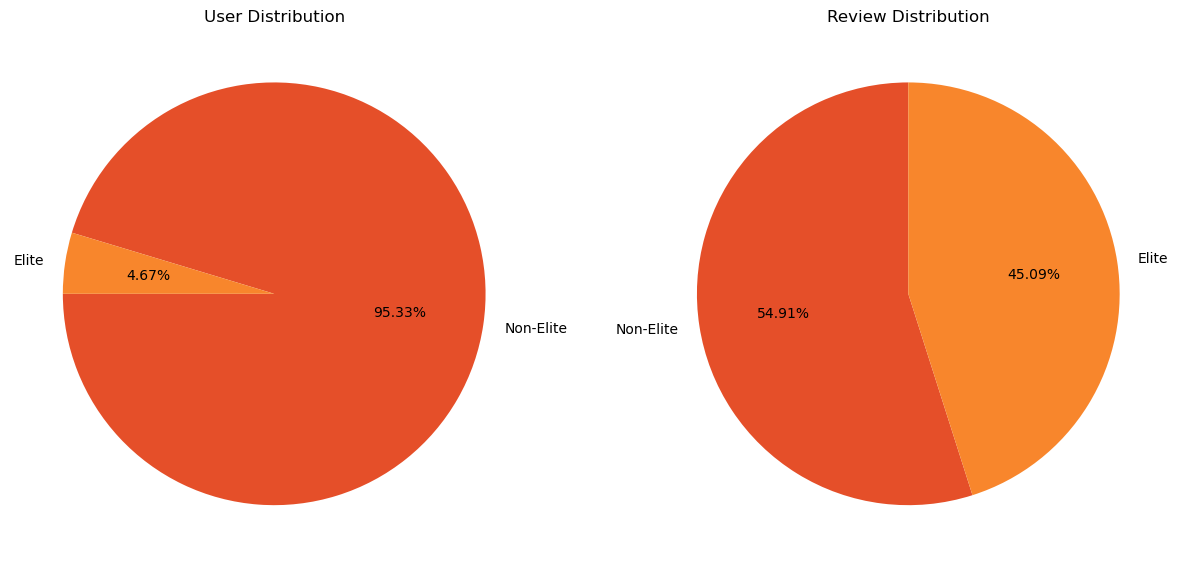

In [104]:
plt.figure(figsize=(15, 8))
plt.subplot(1,2,1)
plt.title('User Distribution')
plt.pie(elite_df['num_users'], labels = elite_df['elite'], autopct='%.2f%%', startangle = 180, colors = ['#E54F29', '#F8862C'])

plt.subplot(1,2,2)
plt.title('Review Distribution')
plt.pie(elite_df['total_review_count'], labels = elite_df['elite'], autopct='%.2f%%', startangle = 90, colors = ['#E54F29', '#F8862C'])

plt.show()

### Busiest Hours

In [99]:
review_engagement = pd.read_sql_query("""
SELECT
  CAST (strftime('%H', date) AS INTEGER) AS hour,
  COUNT(*) AS review_count
FROM review
GROUP BY hour;
""", conn)

tip_engagement = pd.read_sql_query("""
SELECT
  CAST (strftime('%H', date) AS INTEGER) AS hour,
  COUNT(*) AS tip_count
FROM tip
GROUP BY hour;
""", conn)

checkin = pd.read_sql_query(""" SELECT date FROM checkin""", conn)
checkin_engagement = []
for i in checkin['date']:
  checkin_engagement.extend([datetime.strptime(j.strip(), '%Y-%m-%d %H:%M:%S').strftime('%H') for j in i.split(',')])

checkin_engagement = pd.DataFrame(checkin_engagement).astype('int').groupby(0)[[0]].count()

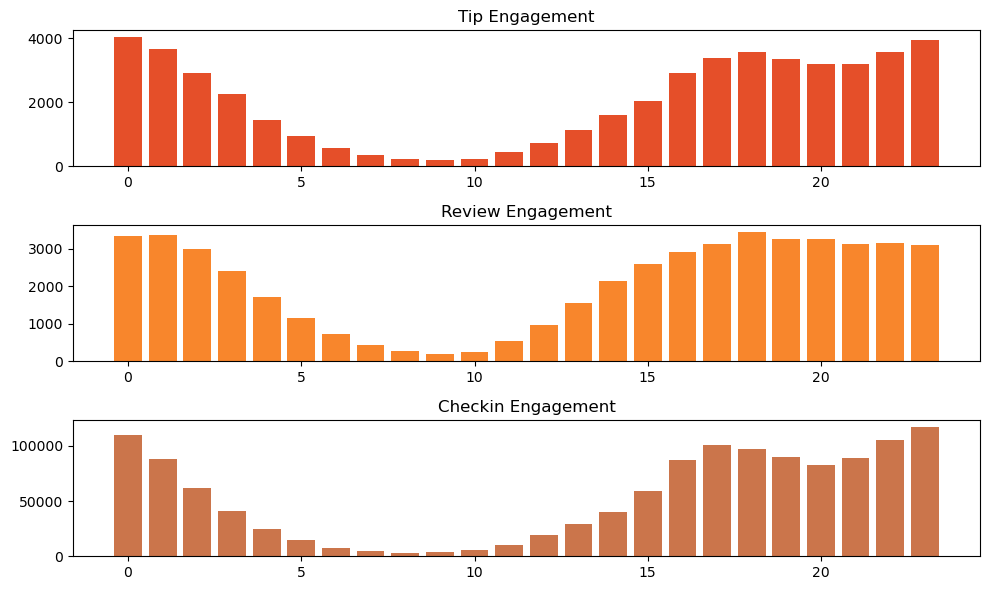

In [103]:
plt.figure(figsize=(10, 6))
plt.subplot(3,1,1)
plt.title('Tip Engagement')
plt.bar(tip_engagement['hour'], tip_engagement['tip_count'], color = '#E54F29')

plt.subplot(3,1,2)
plt.title('Review Engagement')
plt.bar(review_engagement['hour'], review_engagement['review_count'], color = '#F8862C')

plt.subplot(3,1,3)
plt.title('Checkin Engagement')
plt.bar(checkin_engagement.index, checkin_engagement[0], color = '#CB754B')

plt.tight_layout()
plt.show()